In [ ]:
# K-MEANS ALGORITHM 

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn import datasets
import numpy as np

In [5]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)
iris_df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


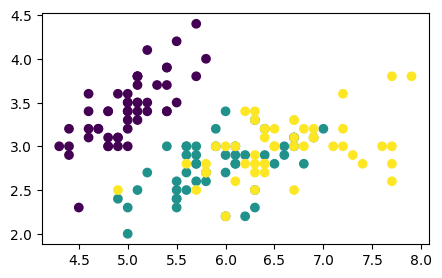

In [7]:
iris_df['target'] = iris.target
plt.figure(figsize=(5, 3))
plt.scatter(iris_df['sepal length (cm)'], iris_df['sepal width (cm)'], c=iris_df['target'])



In [5]:
iris_df.shape

(150, 4)

In [6]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
# finding the optimum number of clusters for k-means classification
x = iris_df.values # extract feature value
y = iris.target # actual labels

In [24]:


from sklearn.cluster import KMeans
wcss = []  # within cluster sum of square

for i in range (1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++',
                    max_iter = 380 , n_init = 10, random_state = 0 )
    kmeans.fit(x)
    wcss.append(kmeans.inertia_ )



    

In [11]:
wcss

[781.3706,
 179.05358288770057,
 87.22062785114048,
 66.84213762993764,
 50.35762078227297,
 42.87479277244494,
 35.63130599995819,
 31.378597465336597,
 29.152287650945546,
 27.545713197621097]

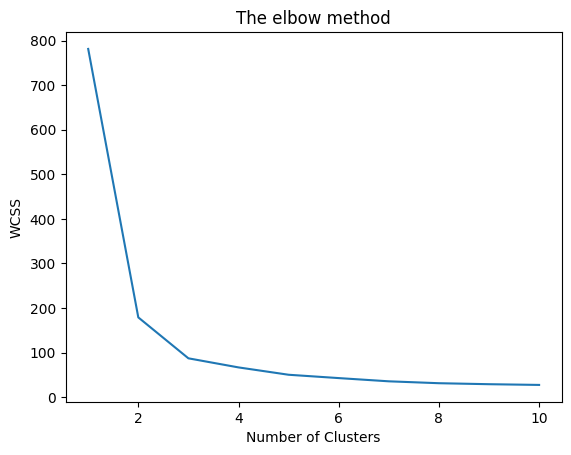

In [10]:
#plotting the results onto a line graph, allowing us to observe 'the elbow'

plt.plot(range(1,11),wcss)
plt.title('The elbow method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [13]:
# Applying k-means  to the iris dataset and creating kmeans cluster

kmeans = KMeans(n_clusters = 3, init = 'k-means++',
                max_iter = 300, n_init = 10, random_state = 0)
y_kmeans = kmeans.fit_predict(x)

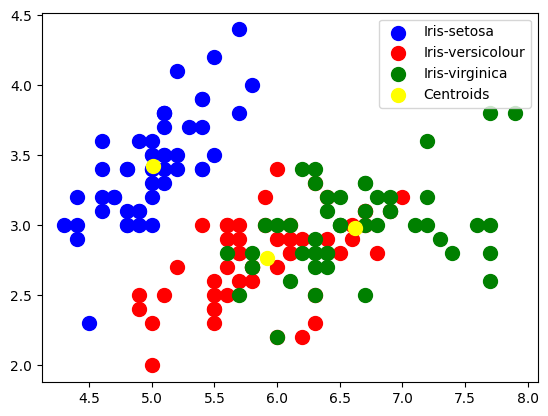

In [14]:
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], 
            s = 100, c = 'blue', label = 'Iris-setosa')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], 
            s = 100, c = 'red', label = 'Iris-versicolour')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1],
            s = 100, c = 'green', label = 'Iris-virginica')

# Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], 
            s = 100, c = 'yellow', label = 'Centroids')

plt.legend()

In [21]:
from scipy.stats import mode
# Mapping k-means labels to actual labels 
def map_clusters_to_labels(y, y_kmeans):
    labels = np.zeros_like(y_kmeans)
    for i in range(3):  # Since we know there are 3 classes
        mask = (y_kmeans == i)
        labels[mask] = mode(y[mask])[0]  # Assign the most common true label
    return labels

In [22]:
y_mapped = map_clusters_to_labels(y,y_kmeans)

In [27]:
# Calculate Accuracy
from sklearn.metrics import accuracy_score, adjusted_rand_score

accuracy = accuracy_score(y, y_mapped)
ari = adjusted_rand_score(y, y_kmeans)


In [28]:
accuracy

0.9933333333333333

In [29]:
ari

0.97993200471804